# Wikipedia Exploration: BFS vs DFS

This notebook runs the same starting page through two different traversal strategies and shows how the choice of data structure (Queue vs Stack) completely changes what gets discovered.

| Strategy | Frontier | Behaviour |
|---|---|---|
| BFS | Queue (FIFO) | Layer-by-layer — stays near the start topic |
| DFS | Stack (LIFO) | Dives deep — reaches unrelated topics quickly |

In [1]:
import sys
sys.path.insert(0, "..")

from src import BFSFrontier, DFSFrontier, WikiScraper, WikiExplorer
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

## Configuration

Adjust `START_PAGE`, `MAX_PAGES`, and `MAX_DEPTH` here. The explorer stops at whichever limit is hit first.

- `MAX_DEPTH = 1` → only direct links from the start page
- `MAX_DEPTH = 2` → direct links + their links
- `MAX_DEPTH = None` → no depth limit, only page count

In [2]:
START_PAGE = "cat"
MAX_PAGES  = 30
MAX_DEPTH  = 2       

SCRAPER = WikiScraper(delay=0.3)

## Run BFS exploration

In [3]:
print("=" * 55)
print("BFS  (Queue / FIFO / layer-by-layer)")
print("=" * 55)

bfs_explorer = WikiExplorer(
    BFSFrontier(), scraper=SCRAPER,
    max_pages=MAX_PAGES, max_depth=MAX_DEPTH, verbose=True
)
bfs_graph = bfs_explorer.explore(START_PAGE)
print(f"\nBFS result: {bfs_graph}")

BFS  (Queue / FIFO / layer-by-layer)
[BFS |   1/30 depth=0] cat
[BFS |   2/30 depth=1] Felidae
[BFS |   3/30 depth=1] Cat (disambiguation)
[BFS |   4/30 depth=1] Cats (disambiguation)
[BFS |   5/30 depth=1] Megaannum
[BFS |   6/30 depth=1] Precambrian
[BFS |   7/30 depth=1] Cambrian
[BFS |   8/30 depth=1] Ordovician
[BFS |   9/30 depth=1] Silurian
[BFS |  10/30 depth=1] Devonian
[BFS |  11/30 depth=1] Carboniferous
[BFS |  12/30 depth=1] Permian
[BFS |  13/30 depth=1] Triassic
[BFS |  14/30 depth=1] Jurassic
[BFS |  15/30 depth=1] Cretaceous
[BFS |  16/30 depth=1] Paleogene
[BFS |  17/30 depth=1] Neogene
[BFS |  18/30 depth=1] Holocene
[BFS |  19/30 depth=1] Conservation status
[BFS |  20/30 depth=1] Taxonomy (biology)
[BFS |  21/30 depth=1] Animal
[BFS |  22/30 depth=1] Chordate
[BFS |  23/30 depth=1] Mammal
[BFS |  24/30 depth=1] Carnivora
[BFS |  25/30 depth=1] Felis
[BFS |  26/30 depth=1] Binomial nomenclature
[BFS |  27/30 depth=1] Carl Linnaeus
[BFS |  28/30 depth=1] 10th edition

## Run DFS exploration

In [4]:
print("=" * 55)
print("DFS  (Stack / LIFO / deep-dive)")
print("=" * 55)

dfs_explorer = WikiExplorer(
    DFSFrontier(), scraper=SCRAPER,
    max_pages=MAX_PAGES, max_depth=MAX_DEPTH, verbose=True
)
dfs_graph = dfs_explorer.explore(START_PAGE)
print(f"\nDFS result: {dfs_graph}")

DFS  (Stack / LIFO / deep-dive)
[DFS |   1/30 depth=0] cat
[DFS |   2/30 depth=1] ZooBank
[DFS |   3/30 depth=2] Wikidata
[DFS |   4/30 depth=2] ISSN (identifier)
[DFS |   5/30 depth=2] Encyclopedia of Life
[DFS |   6/30 depth=2] LiveScience
[DFS |   7/30 depth=2] New Scientist
[DFS |   8/30 depth=2] The New York Times
[DFS |   9/30 depth=2] S2CID (identifier)
[DFS |  10/30 depth=2] Nature (journal)
[DFS |  11/30 depth=2] Zootaxa
[DFS |  12/30 depth=2] PMID (identifier)
[DFS |  13/30 depth=2] PMC (identifier)
[DFS |  14/30 depth=2] Doi (identifier)
[DFS |  15/30 depth=2] Bibcode (identifier)
[DFS |  16/30 depth=2] PLOS One
[DFS |  17/30 depth=2] Plazi
[DFS |  18/30 depth=2] Periodical
[DFS |  19/30 depth=2] Biological type
[DFS |  20/30 depth=2] Academic authorship
[DFS |  21/30 depth=2] Journal article
[DFS |  22/30 depth=2] Lectotypification
[DFS |  23/30 depth=2] Chromis abyssus
[DFS |  24/30 depth=2] ICZN Code
[DFS |  25/30 depth=2] Thomson Reuters
[DFS |  26/30 depth=2] Zoological

## Side-by-side comparison

In [ ]:
bfs_only = bfs_graph.visited - dfs_graph.visited
dfs_only = dfs_graph.visited - bfs_graph.visited
shared   = bfs_graph.visited & dfs_graph.visited

print(f"Pages visited by BOTH    : {len(shared)}")
print(f"Pages visited by BFS only: {len(bfs_only)}")
print(f"  → {sorted(bfs_only)}")
print(f"Pages visited by DFS only: {len(dfs_only)}")
print(f"  → {sorted(dfs_only)}")
print()
print("BFS stays close to the start topic.")
print("DFS wanders — its unique pages will look unrelated.")

Pages visited by BOTH    : 1
Pages visited by BFS only: 29
  → ['10th edition of Systema Naturae', 'Animal', 'Binomial nomenclature', 'Cambrian', 'Carboniferous', 'Carl Linnaeus', 'Carnivora', 'Cat (disambiguation)', 'Cats (disambiguation)', 'Chordate', 'Conservation status', 'Cretaceous', 'Devonian', 'Felidae', 'Felis', 'Holocene', 'Johann Christian Polycarp Erxleben', 'Jurassic', 'Mammal', 'Megaannum', 'Neogene', 'Ordovician', 'Paleogene', 'Permian', 'Precambrian', 'Silurian', 'Synonym (taxonomy)', 'Taxonomy (biology)', 'Triassic']
Pages visited by DFS only: 29
  → ['Academic authorship', 'Bibcode (identifier)', 'Biological type', 'Chromis abyssus', 'Doi (identifier)', 'Encyclopedia of Life', 'Globally unique identifier', 'ICZN Code', 'ICZN Code of Nomenclature', 'ISSN (identifier)', 'Index to Organism Names', 'Journal article', 'Lectotypification', 'LiveScience', 'Nature (journal)', 'New Scientist', 'PLOS One', 'PMC (identifier)', 'PMID (identifier)', 'Periodical', 'Plazi', 'S2CID (

## Visualise BFS subgraph — radial / wide

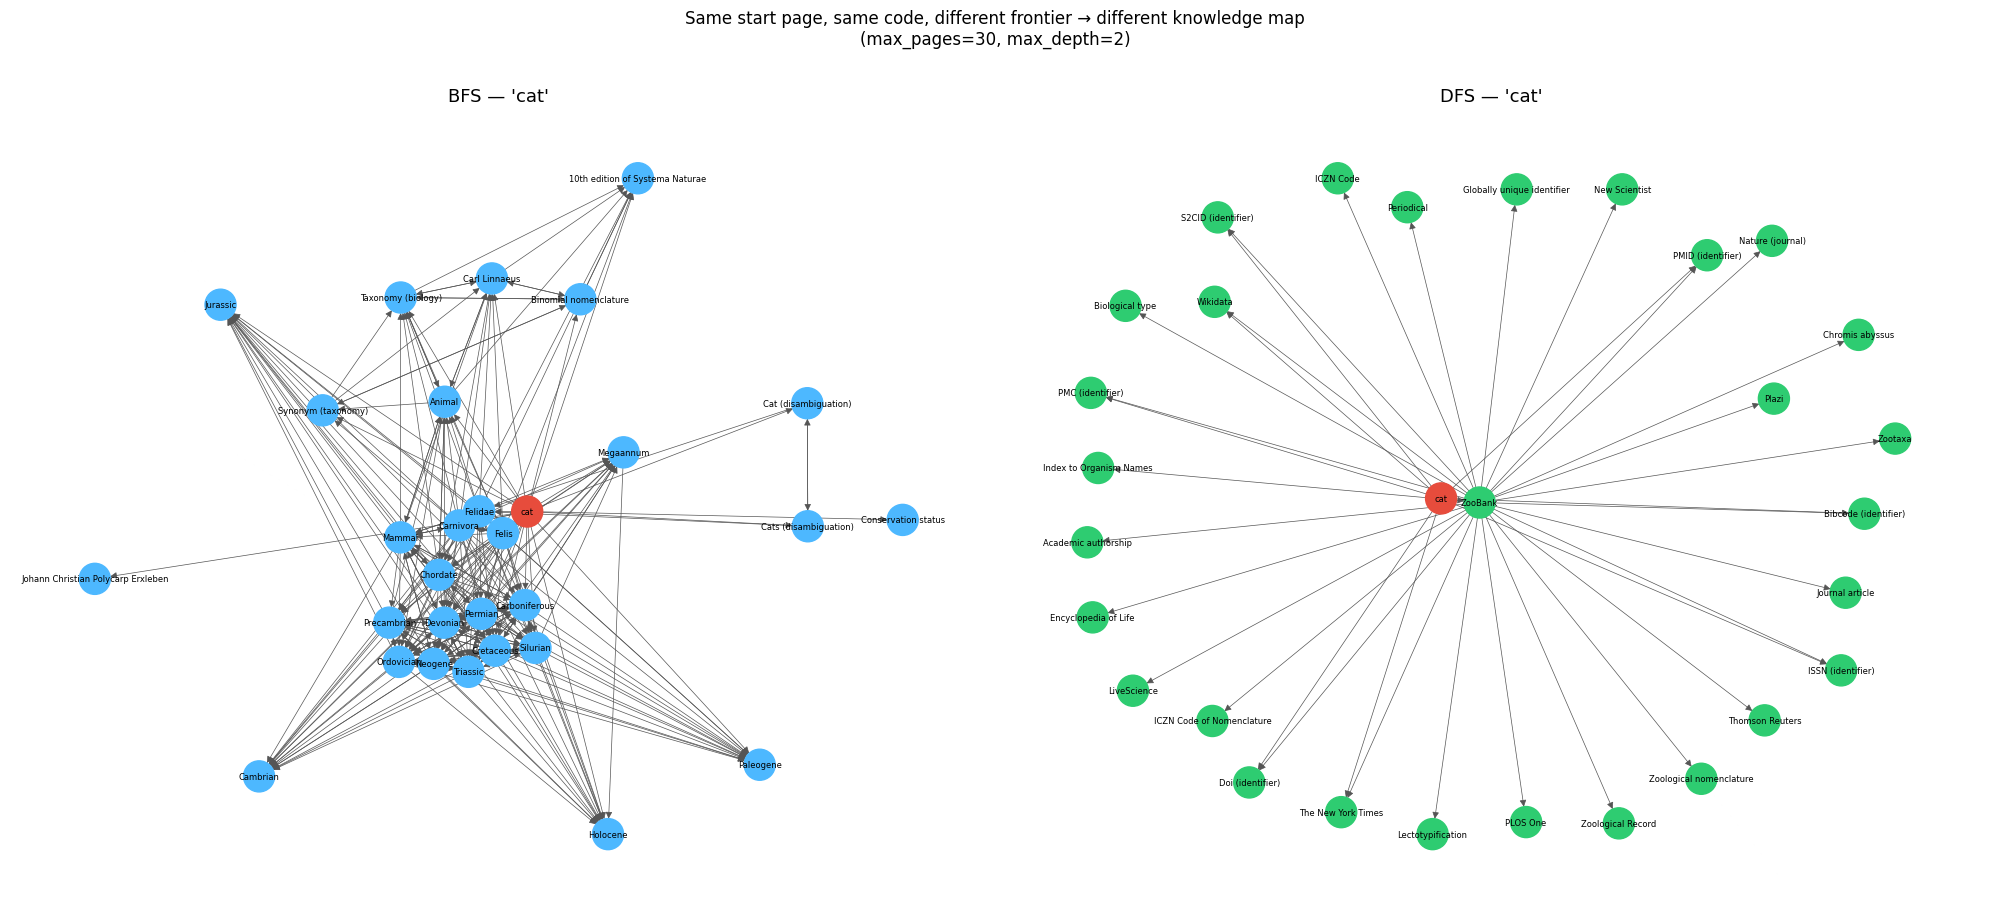

In [6]:
def build_nx_graph(wiki_graph, limit=25):
    G = nx.DiGraph()
    visited_list = list(wiki_graph.visited)[:limit]
    for source in visited_list:
        for target in wiki_graph.neighbors(source):
            if target in wiki_graph.visited:
                G.add_edge(source, target)
    return G

fig, axes = plt.subplots(1, 2, figsize=(20, 9))

for ax, graph, title, color in [
    (axes[0], bfs_graph, f"BFS — '{START_PAGE}'", "#4DB8FF"),
    (axes[1], dfs_graph, f"DFS — '{START_PAGE}'", "#2ecc71"),
]:
    G = build_nx_graph(graph)
    pos = nx.spring_layout(G, seed=42, k=0.9)
    node_colors = ["#e74c3c" if n == START_PAGE else color for n in G.nodes()]
    nx.draw_networkx(
        G, pos, ax=ax,
        node_color=node_colors, node_size=500,
        font_size=6, arrows=True, edge_color="#555", width=0.5,
    )
    ax.set_title(title, fontsize=13)
    ax.axis("off")

plt.suptitle(
    f"Same start page, same code, different frontier → different knowledge map\n"
    f"(max_pages={MAX_PAGES}, max_depth={MAX_DEPTH})",
    fontsize=12, y=1.01
)
plt.tight_layout()
plt.savefig("exploration_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## What the depth limit does

Re-run the cells below with different `max_depth` values to see how the exploration changes:

| `max_depth` | What gets visited |
|---|---|
| `1` | Only direct links from the start page |
| `2` | Direct links + one more hop |
| `3` | Three hops out — concepts start becoming less related |
| `None` | No depth limit — only the page count cap applies |

For BFS this is intuitive: depth 1 = layer 1, depth 2 = layers 1+2.  
For DFS the depth limit cuts off the dive at a fixed number of hops, preventing it from going arbitrarily far in one direction.

In [7]:
# Depth experiment: BFS at depth=1 vs depth=2
for depth in [1, 2]:
    exp = WikiExplorer(
        BFSFrontier(), scraper=SCRAPER,
        max_pages=100, max_depth=depth, verbose=False
    )
    g = exp.explore(START_PAGE)
    print(f"BFS depth={depth}: {g.node_count()} pages visited")
    print(f"  Unique pages: {sorted(g.visited)[:8]} ...\n")

BFS depth=1: 100 pages visited
  Unique pages: ['10th edition of Systema Naturae', 'Animal', 'Animal population control', 'Archaeology', 'Autumn', 'BCE', 'Binomial nomenclature', 'Bird'] ...

BFS depth=2: 100 pages visited
  Unique pages: ['10th edition of Systema Naturae', 'Animal', 'Animal population control', 'Archaeology', 'Autumn', 'BCE', 'Binomial nomenclature', 'Bird'] ...

